<a href="https://colab.research.google.com/github/akshitasharmamca2025-jpg/17-feb/blob/main/sales_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Order_ID     Product     Category  Price  Quantity        Date     City
0       101      Mobile  Electronics  15000         2  2023-01-10    Delhi
1       102       Shoes      Fashion   2000         1  2023-01-11   Mumbai
2       103      Laptop  Electronics  50000         1  2023-02-05    Delhi
3       104     T-shirt      Fashion    800         3  2023-02-10  Chennai
4       105  Headphones  Electronics   1500         2  2023-03-01   Mumbai

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  10 non-null     int64 
 1   Product   10 non-null     object
 2   Category  10 non-null     object
 3   Price     10 non-null     int64 
 4   Quantity  10 non-null     int64 
 5   Date      10 non-null     object
 6   City      10 non-null     object
dtypes: int64(3), object(4)
memory usage: 692.0+ bytes
None

Missing Values:
Orde

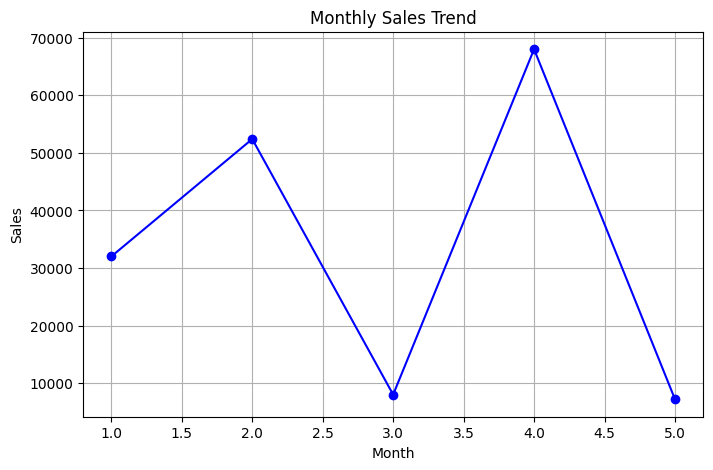

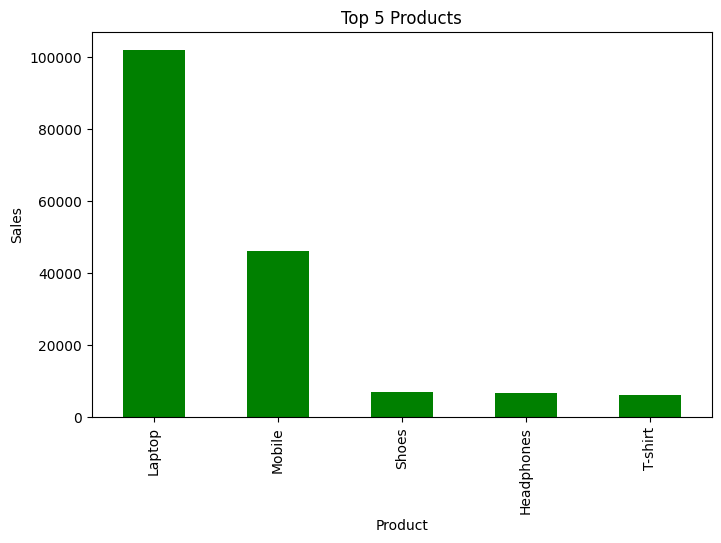

/tmp/ipykernel_182/1719224386.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis') # Using seaborn for a slightly different aesthetic


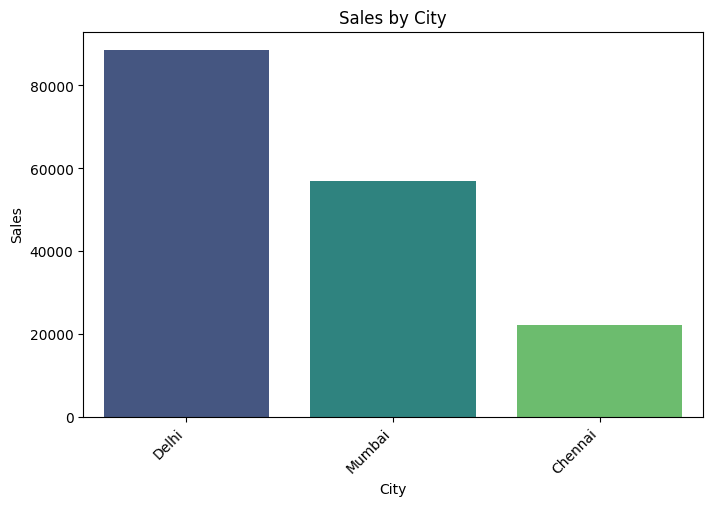

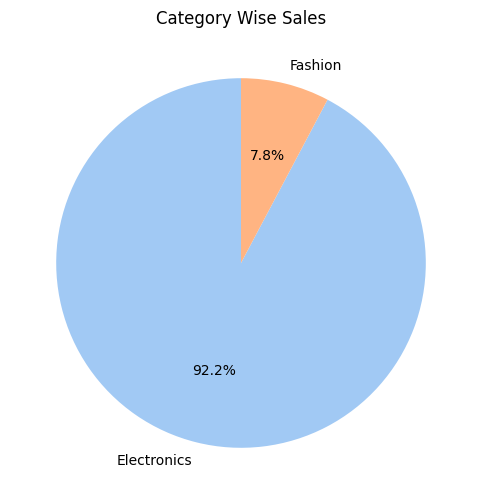


--- Insights ---
1. Total Revenue Generated: 167600
2. Top Selling Product: Laptop
3. Best Performing City: Delhi
4. Best Month: 4
5. Highest Sales Category: Electronics


In [6]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set matplotlib to display plots inline in the notebook
%matplotlib inline

# Sample data creation: Define a dictionary containing sales data
data = {
    "Order_ID": [101,102,103,104,105,106,107,108,109,110],
    "Product": ["Mobile","Shoes","Laptop","T-shirt","Headphones","Shoes","Mobile","Laptop","T-shirt","Headphones"],
    "Category": ["Electronics","Fashion","Electronics","Fashion","Electronics","Fashion","Electronics","Electronics","Fashion","Electronics"],
    "Price": [15000,2000,50000,800,1500,2500,16000,52000,900,1800],
    "Quantity": [2,1,1,3,2,2,1,1,4,2],
    "Date": ["2023-01-10","2023-01-11","2023-02-05","2023-02-10","2023-03-01",
             "2023-03-15","2023-04-01","2023-04-18","2023-05-05","2023-05-20"],
    "City": ["Delhi","Mumbai","Delhi","Chennai","Mumbai","Delhi","Chennai","Mumbai","Delhi","Chennai"]
}

# Create a pandas DataFrame from the sample data
df = pd.DataFrame(data)

# Data Overview: Print the first 5 rows of the DataFrame
print("First 5 rows:")
print(df.head())

# Data Overview: Print information about the DataFrame, including data types and non-null values
print("\nData Info:")
print(df.info())

# Data Overview: Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Data Preprocessing: Convert 'Date' column to datetime objects for time-based operations
df['Date'] = pd.to_datetime(df['Date'])

# Feature Engineering: Calculate 'Total_Sales' for each order
df['Total_Sales'] = df['Price'] * df['Quantity']

# Feature Engineering: Extract 'Month' from the 'Date' column
df['Month'] = df['Date'].dt.month

# Display the DataFrame with new columns
print("\nUpdated Data:")
print(df.head())

# Sales Analysis: Calculate total sales revenue
total_sales = df['Total_Sales'].sum()
print("\nTotal Sales:", total_sales)

# Sales Analysis: Group sales by product and find top products
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
print("\nTop Products:\n", top_products)

# Sales Analysis: Group sales by city
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
print("\nSales by City:\n", city_sales)

# Sales Analysis: Group sales by month
monthly_sales = df.groupby('Month')['Total_Sales'].sum()
print("\nMonthly Sales:\n", monthly_sales)

# Sales Analysis: Group sales by category
category_sales = df.groupby('Category')['Total_Sales'].sum()
print("\nCategory Sales:\n", category_sales)

# Visualization: Plot Monthly Sales Trend (Line Plot)
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Visualization: Plot Top 5 Products (Bar Plot)
plt.figure(figsize=(8,5))
top_products.head().plot(kind='bar', color='green')
plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

# Visualization: Plot Sales by City (Bar Plot using Seaborn)
plt.figure(figsize=(8,5))
sns.barplot(x=city_sales.index, y=city_sales.values, hue=city_sales.index, palette='viridis', legend=False) # Using seaborn for a slightly different aesthetic, addressing FutureWarning
plt.title("Sales by City")
plt.xlabel("City") # Added x-label for clarity
plt.ylabel("Sales") # Added y-label for clarity
plt.xticks(rotation=45, ha='right') # Rotate and align x-axis labels
plt.show()

# Visualization: Plot Category Wise Sales (Pie Chart)
plt.figure(figsize=(6,6))
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(category_sales)]) # Added startangle and colors
plt.title("Category Wise Sales")
plt.ylabel("") # Remove default y-label for pie chart
plt.show()

# Insights Summary: Print key findings from the analysis
print("\n--- Insights ---")
print("1. Total Revenue Generated:", total_sales)
print("2. Top Selling Product:", top_products.idxmax())
print("3. Best Performing City:", city_sales.idxmax())
print("4. Best Month:", monthly_sales.idxmax())
print("5. Highest Sales Category:", category_sales.idxmax())